# 0630 과제 개선 반영 노트북

이 노트북은 수행 예시 `benchmark_baseline.ipynb`의 baseline 구조를 유지하되, 다음 개선 사항을 반영한 버전입니다.

- Train / Validation 분리
- `summary_len` 오타 수정
- Train/Test 토큰화 방식 통일
- LSTM이 PAD 토큰을 읽지 않도록 `attention_mask` + `pack_padded_sequence` 적용
- `padding_idx` 적용
- `helpful_yes`, `helpful_total`에 `log1p` 변환 적용
- target scaling으로 loss scale 문제 완화
- `unixReviewTime`, `len`, `summary_len` 수치형 feature 추가
- Validation MAE / RMSE 출력
- 예측값 후처리: `overall` 범위 제한, helpful 음수 방지, `helpful_yes <= helpful_total` 보정

In [1]:

# 필요 시 한 번만 실행하세요.
# 이전에 transformers / huggingface_hub ImportError가 났다면 아래 셀의 주석을 풀고 실행한 뒤 커널을 재시작하세요.

# %pip uninstall -y transformers huggingface-hub tokenizers safetensors
# %pip install --no-cache-dir --force-reinstall transformers huggingface-hub tokenizers safetensors

In [2]:

# 데이터 파일 다운로드
# train.jsonl, test.jsonl, submission.csv가 이미 현재 폴더에 있으면 다운로드를 건너뜁니다.

from pathlib import Path
import shutil

required_files = ["train.jsonl", "test.jsonl", "submission.csv"]
missing_files = [f for f in required_files if not Path(f).exists()]

if missing_files:
    from huggingface_hub import hf_hub_download

    repo_id = "hongdune/BenchMarkDataset"
    repo_type = "dataset"

    for filename in missing_files:
        path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            repo_type=repo_type
        )
        shutil.copy(path, filename)
        print(f"saved: {filename}")
else:
    print("모든 데이터 파일이 이미 존재합니다.")

모든 데이터 파일이 이미 존재합니다.


In [3]:

import ast
import copy
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from transformers import BertTokenizer

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [4]:

# 데이터 로드
df = pd.read_json("train.jsonl", lines=True)
print(df.shape)
df.head()

(9234, 10)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,row_id
0,A1K582XYLTKUCD,B0042F1L4S,"Coder10 ""Ricardo""","[0, 1]",im not a profesional player but i like to play...,5,Everything a hobbiest want,1361404800,"02 21, 2013",8492
1,A2J4UAF6RW13WK,B000EELB8W,Michael W DeSilva,"[0, 0]",This is just an excellent product. I have been...,5,Excellent Product,1371686400,"06 20, 2013",4666
2,A3OXHLG6DIBRW8,B000BU5V58,"C. Hill ""CFH""","[1, 1]","We opted for the World Tour ""Guitar Gig Bag"" o...",4,Roomy Guitar Case - Recommended,1290556800,"11 24, 2010",4286
3,A3872Y2XH0YDX1,B000CZ0RLK,Amazon Customer,"[0, 0]","This is not a top tier condenser mic, but it i...",5,definitely a good value,1311552000,"07 25, 2011",4446
4,A2G3VQU2GRN8BU,B000978D58,"Moral Hazard ""D""","[1, 3]",This could be used for lightweight microphones...,3,Too cheap.,1316044800,"09 15, 2011",3921


,helpful_yes,helpful_total
count,9234.000000,9234.000000
mean,1.571475,1.859108
std,8.973910,9.526012
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,290.000000,300.000000


helpful_yes가 0인 비율: 0.7024041585445094
helpful_yes가 0인 개수: 6486
helpful_total이 0인 비율: 0.6621182586094867
helpful_total이 0인 개수: 6114


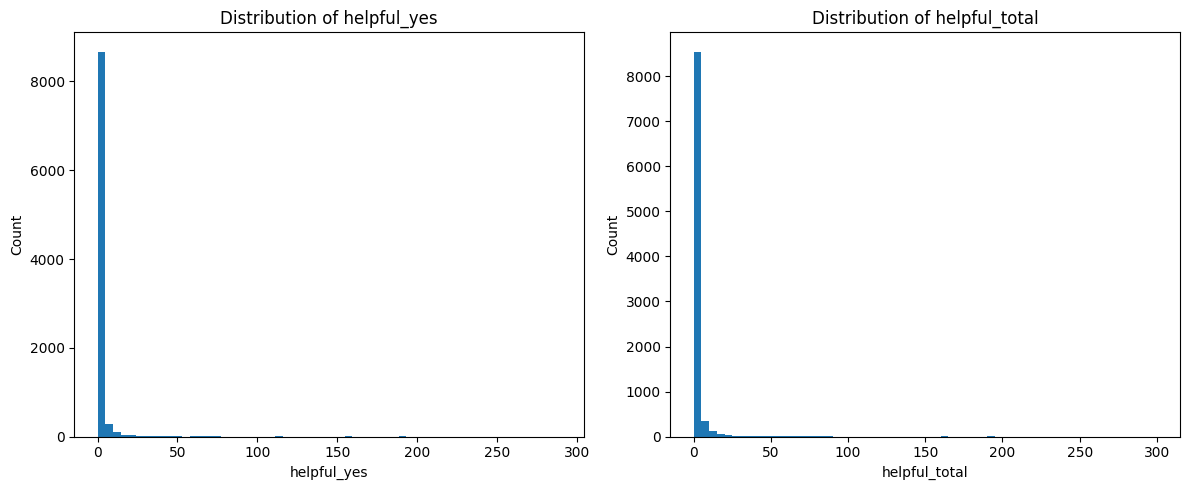

In [25]:
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
train_path = "train.jsonl"
df = pd.read_json(train_path, lines=True)

# 2. helpful 컬럼이 [yes, total] 형태일 때 분리
def parse_helpful(x):
    if isinstance(x, list) and len(x) == 2:
        return x[0], x[1]
    if isinstance(x, str):
        y = ast.literal_eval(x)
        return y[0], y[1]
    return 0, 0

df["helpful_yes"], df["helpful_total"] = zip(*df["helpful"].apply(parse_helpful))

# 3. 기초 통계량 확인
display(df[["helpful_yes", "helpful_total"]].describe())

# 4. 0 비율 확인
print("helpful_yes가 0인 비율:", (df["helpful_yes"] == 0).mean())
print("helpful_yes가 0인 개수:", (df["helpful_yes"] == 0).sum())
print("helpful_total이 0인 비율:", (df["helpful_total"] == 0).mean())
print("helpful_total이 0인 개수:", (df["helpful_total"] == 0).sum())

# 5. helpful_yes, helpful_total 히스토그램
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["helpful_yes"], bins=60)
plt.title("Distribution of helpful_yes")
plt.xlabel("helpful_yes")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(df["helpful_total"], bins=60)
plt.title("Distribution of helpful_total")
plt.xlabel("helpful_total")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:

# helpful 컬럼 분리
# helpful = [도움됨 수, 전체 평가 수]

def parse_helpful(x):
    if isinstance(x, list) and len(x) == 2:
        return x[0], x[1]
    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, list) and len(y) == 2:
                return y[0], y[1]
        except (ValueError, SyntaxError):
            pass
    return 0, 0

df["helpful_yes"], df["helpful_total"] = zip(*df["helpful"].apply(parse_helpful))

# 기본 결측 처리
for col in ["reviewText", "summary"]:
    df[col] = df[col].fillna("").astype(str)

# 길이 feature 생성: summery_len 오타를 summary_len으로 수정
df["len"] = df["reviewText"].apply(lambda x: len(x.split()))
df["summary_len"] = df["summary"].apply(lambda x: len(x.split()))

# 시간 컬럼 결측 처리
if "unixReviewTime" in df.columns:
    df["unixReviewTime"] = df["unixReviewTime"].fillna(df["unixReviewTime"].median())
else:
    df["unixReviewTime"] = 0

# 데이터 보정
# helpful_yes는 helpful_total보다 클 수 없다는 제약을 반영
df.loc[df["helpful_yes"] > df["helpful_total"], "helpful_yes"] = df.loc[
    df["helpful_yes"] > df["helpful_total"], "helpful_total"
]

# helpful target은 긴 꼬리 분포 가능성이 있으므로 log1p 변환
df["helpful_yes_log"] = np.log1p(df["helpful_yes"].clip(lower=0))
df["helpful_total_log"] = np.log1p(df["helpful_total"].clip(lower=0))

df[["overall", "unixReviewTime", "helpful_yes", "helpful_total", "len", "summary_len"]].describe()

,overall,unixReviewTime,helpful_yes,helpful_total,len,summary_len
count,9234.000000,9.234000e+03,9234.000000,9234.000000,9234.000000,9234.000000
mean,4.490903,1.360563e+09,1.571475,1.859108,90.338965,4.376760
std,0.897168,3.784815e+07,8.973910,9.526012,109.347447,2.857689
min,1.000000,1.095466e+09,0.000000,0.000000,0.000000,1.000000
25%,4.000000,1.343434e+09,0.000000,0.000000,31.000000,2.000000
50%,5.000000,1.368403e+09,0.000000,0.000000,54.000000,4.000000
75%,5.000000,1.388880e+09,1.000000,1.000000,105.000000,6.000000
max,5.000000,1.405987e+09,290.000000,300.000000,2043.000000,25.000000


In [ ]:
# 길이 분포 확인
# MAX_LEN은 고정값으로 두되, 실제 tokenizer 기준 길이도 함께 확인합니다.

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

word_len_desc = df[["len", "summary_len"]].describe(percentiles=[0.5, 0.75, 0.9, 0.95])
word_len_desc

,len,summary_len
count,9234.000000,9234.000000
mean,90.338965,4.376760
std,109.347447,2.857689
min,0.000000,1.000000
50%,54.000000,4.000000
75%,105.000000,6.000000
90%,194.000000,8.000000
95%,283.000000,10.000000
max,2043.000000,25.000000


In [7]:
# tokenizer 기준 길이 일부 확인
# 전체 데이터가 크더라도 9천여 건 수준에서는 전체 계산 가능하지만, 속도를 위해 sample도 허용합니다.

sample_df = df.sample(min(len(df), 3000), random_state=SEED)

review_token_lens = sample_df["reviewText"].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)
summary_token_lens = sample_df["summary"].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

print("review token length")
print(review_token_lens.describe(percentiles=[0.5, 0.75, 0.9, 0.95]))
print("\nsummary token length")
print(summary_token_lens.describe(percentiles=[0.5, 0.75, 0.9, 0.95]))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (619 > 512). Running this sequence through the model will result in indexing errors


review token length
count    3000.000000
mean      116.880333
std       144.940415
min         2.000000
50%        68.000000
75%       131.000000
90%       255.100000
95%       385.050000
max      1812.000000
Name: reviewText, dtype: float64

summary token length
count    3000.000000
mean        7.765000
std         3.951326
min         3.000000
50%         7.000000
75%        10.000000
90%        13.000000
95%        15.050000
max        36.000000
Name: summary, dtype: float64


In [8]:

# 최대 길이 설정
# 예시의 100/10은 유지하되, BERT 계열에서 다루기 쉬운 값으로 약간 여유를 둡니다.
# 학습 시간이 너무 오래 걸리면 MAX_LEN_REVIEW를 100으로 낮춰도 됩니다.

MAX_LEN_REVIEW = 128
MAX_LEN_SUMMARY = 16
BATCH_SIZE = 32

In [9]:

# Train / Validation 분리
# overall이 1~5점 클래스처럼 분포한다면 stratify를 사용해 평점 분포를 유지합니다.

try:
    stratify_col = df["overall"].astype(int)
    train_df, valid_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=stratify_col
    )
except ValueError:
    train_df, valid_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED
    )

train_df = train_df.reset_index(drop=True).copy()
valid_df = valid_df.reset_index(drop=True).copy()

print("train:", train_df.shape)
print("valid:", valid_df.shape)

train: (7387, 16)
valid: (1847, 16)


In [ ]:
# 수치형 feature scaling과 target scaling
# scaling은 반드시 train 데이터에 fit하고, valid/test에는 transform만 적용합니다.

NUMERIC_COLS = ["unixReviewTime", "len", "summary_len"]
TARGET_COLS = ["overall", "helpful_yes_log", "helpful_total_log"]
SCALED_TARGET_COLS = ["overall_scaled", "helpful_yes_log_scaled", "helpful_total_log_scaled"]

numeric_scaler = StandardScaler()
train_df[NUMERIC_COLS] = numeric_scaler.fit_transform(train_df[NUMERIC_COLS])
valid_df[NUMERIC_COLS] = numeric_scaler.transform(valid_df[NUMERIC_COLS])

target_scaler = StandardScaler()
train_df[SCALED_TARGET_COLS] = target_scaler.fit_transform(train_df[TARGET_COLS])
valid_df[SCALED_TARGET_COLS] = target_scaler.transform(valid_df[TARGET_COLS])

train_df[NUMERIC_COLS + SCALED_TARGET_COLS].head()

,unixReviewTime,len,summary_len,overall_scaled,helpful_yes_log_scaled,helpful_total_log_scaled
0,-0.008165,-0.475834,-1.172439,0.567499,-0.514858,-0.563023
1,-1.037753,0.158076,-0.125225,0.567499,0.453816,0.338003
2,-0.788917,1.025041,0.921989,0.567499,-0.514858,-0.563023
3,1.115021,-0.308034,-1.172439,-0.546537,-0.514858,-0.563023
4,0.688119,0.297909,-0.125225,-0.546537,-0.514858,-0.563023


In [11]:

class ReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len_review, max_len_summary, numeric_cols, target_cols=None):
        self.df = df.reset_index(drop=True)
        self.numeric_cols = numeric_cols
        self.target_cols = target_cols

        self.review_enc = tokenizer(
            self.df["reviewText"].tolist(),
            padding="max_length",
            truncation=True,
            max_length=max_len_review,
            return_tensors="pt"
        )
        self.summary_enc = tokenizer(
            self.df["summary"].tolist(),
            padding="max_length",
            truncation=True,
            max_length=max_len_summary,
            return_tensors="pt"
        )

        self.numeric = torch.tensor(
            self.df[numeric_cols].values,
            dtype=torch.float
        )

        if target_cols is not None:
            self.targets = torch.tensor(
                self.df[target_cols].values,
                dtype=torch.float
            )
        else:
            self.targets = None

        if "row_id" in self.df.columns:
            self.row_ids = self.df["row_id"].astype(int).tolist()
        else:
            self.row_ids = list(range(len(self.df)))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = {
            "row_id": torch.tensor(self.row_ids[idx], dtype=torch.long),
            "review_input_ids": self.review_enc["input_ids"][idx],
            "review_attention_mask": self.review_enc["attention_mask"][idx],
            "summary_input_ids": self.summary_enc["input_ids"][idx],
            "summary_attention_mask": self.summary_enc["attention_mask"][idx],
            "numeric": self.numeric[idx],
        }
        if self.targets is not None:
            item["target"] = self.targets[idx]
        return item

train_dataset = ReviewDataset(
    train_df,
    tokenizer,
    MAX_LEN_REVIEW,
    MAX_LEN_SUMMARY,
    NUMERIC_COLS,
    SCALED_TARGET_COLS
)
valid_dataset = ReviewDataset(
    valid_df,
    tokenizer,
    MAX_LEN_REVIEW,
    MAX_LEN_SUMMARY,
    NUMERIC_COLS,
    SCALED_TARGET_COLS
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(k, v.shape)

row_id torch.Size([32])
review_input_ids torch.Size([32, 128])
review_attention_mask torch.Size([32, 128])
summary_input_ids torch.Size([32, 16])
summary_attention_mask torch.Size([32, 16])
numeric torch.Size([32, 3])
target torch.Size([32, 3])


In [12]:

class ImprovedRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, numeric_dim, pad_id=0, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_id
        )

        self.rnn_review = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.rnn_summary = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        text_dim = hidden_dim * 2
        combined_dim = text_dim * 2 + numeric_dim

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.overall_head = nn.Linear(64, 1)
        self.helpful_head = nn.Linear(64, 2)

    def encode_sequence(self, input_ids, attention_mask, rnn_layer):
        embedded = self.embedding(input_ids)

        # attention_mask 합으로 실제 토큰 길이를 계산합니다.
        # pack_padded_sequence는 CPU length를 요구합니다.
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, _) = rnn_layer(packed)

        # bidirectional=True이므로 마지막 forward/backward hidden을 concat합니다.
        encoded = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return encoded

    def forward(
        self,
        review_input_ids,
        review_attention_mask,
        summary_input_ids,
        summary_attention_mask,
        numeric
    ):
        review_vec = self.encode_sequence(
            review_input_ids,
            review_attention_mask,
            self.rnn_review
        )
        summary_vec = self.encode_sequence(
            summary_input_ids,
            summary_attention_mask,
            self.rnn_summary
        )

        combined = torch.cat([review_vec, summary_vec, numeric], dim=1)
        hidden = self.regressor(combined)

        overall_pred = self.overall_head(hidden)
        helpful_pred = self.helpful_head(hidden)

        return torch.cat([overall_pred, helpful_pred], dim=1)

In [ ]:
# 모델 생성

vocab_size = tokenizer.vocab_size
embed_dim = 128
hidden_dim = 64
numeric_dim = len(NUMERIC_COLS)
pad_id = tokenizer.pad_token_id

model = ImprovedRNN(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    numeric_dim=numeric_dim,
    pad_id=pad_id,
    dropout=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

ImprovedRNN(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (rnn_review): LSTM(128, 64, batch_first=True, bidirectional=True)
  (rnn_summary): LSTM(128, 64, batch_first=True, bidirectional=True)
  (regressor): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=259, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (overall_head): Linear(in_features=64, out_features=1, bias=True)
  (helpful_head): Linear(in_features=64, out_features=2, bias=True)
)


In [14]:

def inverse_scaled_targets(arr_scaled):
    # scaled target을 원래 의미의 overall, helpful_yes, helpful_total로 되돌립니다.
    arr = target_scaler.inverse_transform(arr_scaled)

    overall = arr[:, 0]
    helpful_yes = np.expm1(arr[:, 1])
    helpful_total = np.expm1(arr[:, 2])

    # 후처리: 가능한 값 범위로 보정
    overall = np.clip(overall, 1, 5)
    helpful_yes = np.maximum(helpful_yes, 0)
    helpful_total = np.maximum(helpful_total, 0)
    helpful_total = np.maximum(helpful_total, helpful_yes)

    return np.column_stack([overall, helpful_yes, helpful_total])


def compute_metrics(y_true_scaled, y_pred_scaled):
    y_true = inverse_scaled_targets(y_true_scaled)
    y_pred = inverse_scaled_targets(y_pred_scaled)

    names = ["overall", "helpful_yes", "helpful_total"]
    rows = []
    for i, name in enumerate(names):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        rows.append({"target": name, "MAE": mae, "RMSE": rmse})
    return pd.DataFrame(rows)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    preds = []
    trues = []

    for batch in loader:
        review_input_ids = batch["review_input_ids"].to(device)
        review_attention_mask = batch["review_attention_mask"].to(device)
        summary_input_ids = batch["summary_input_ids"].to(device)
        summary_attention_mask = batch["summary_attention_mask"].to(device)
        numeric = batch["numeric"].to(device)
        target = batch["target"].to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(
                review_input_ids,
                review_attention_mask,
                summary_input_ids,
                summary_attention_mask,
                numeric
            )
            loss = criterion(pred, target)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item() * review_input_ids.size(0)
        preds.append(pred.detach().cpu().numpy())
        trues.append(target.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.vstack(preds)
    trues = np.vstack(trues)
    return avg_loss, preds, trues

In [20]:

# 학습
# valid loss가 좋아지는 모델만 저장합니다.

EPOCHS = 10
PATIENCE = 3

best_valid_loss = float("inf")
best_state_dict = None
patience_count = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _ = run_epoch(model, train_loader, optimizer=optimizer)

    with torch.no_grad():
        valid_loss, valid_preds, valid_trues = run_epoch(model, valid_loader, optimizer=None)

    metrics_df = compute_metrics(valid_trues, valid_preds)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "overall_MAE": metrics_df.loc[metrics_df["target"] == "overall", "MAE"].values[0],
        "helpful_yes_MAE": metrics_df.loc[metrics_df["target"] == "helpful_yes", "MAE"].values[0],
        "helpful_total_MAE": metrics_df.loc[metrics_df["target"] == "helpful_total", "MAE"].values[0],
    })

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f}")
    display(metrics_df)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print("Early stopping")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6215 | valid_loss=0.7787


,target,MAE,RMSE
0,overall,0.545788,0.789569
1,helpful_yes,1.764670,9.108318
2,helpful_total,2.027481,9.511906


Epoch 02 | train_loss=0.5251 | valid_loss=0.7899


,target,MAE,RMSE
0,overall,0.515425,0.777032
1,helpful_yes,1.809639,9.028414
2,helpful_total,2.073242,9.437756


Epoch 03 | train_loss=0.4512 | valid_loss=0.8229


,target,MAE,RMSE
0,overall,0.502824,0.779642
1,helpful_yes,1.803646,9.101635
2,helpful_total,2.070040,9.576394


Epoch 04 | train_loss=0.3852 | valid_loss=0.8204


,target,MAE,RMSE
0,overall,0.506845,0.779028
1,helpful_yes,1.819789,9.252247
2,helpful_total,2.079786,9.722004


Early stopping


,epoch,train_loss,valid_loss,overall_MAE,helpful_yes_MAE,helpful_total_MAE
0,1,0.621486,0.778748,0.545788,1.764670,2.027481
1,2,0.525099,0.789946,0.515425,1.809639,2.073242
2,3,0.451164,0.822920,0.502824,1.803646,2.070040
3,4,0.385212,0.820366,0.506845,1.819789,2.079786


In [ ]:
# 최종 validation 성능 확인

model.eval()
with torch.no_grad():
    valid_loss, valid_preds, valid_trues = run_epoch(model, valid_loader, optimizer=None)

print("best valid loss:", valid_loss)
compute_metrics(valid_trues, valid_preds)

best valid loss: 0.747810319396826


,target,MAE,RMSE
0,overall,0.547801,0.784898
1,helpful_yes,1.767889,9.199272
2,helpful_total,2.026458,9.670362


In [17]:

# 테스트 데이터 전처리
# Train과 동일한 tokenizer, MAX_LEN, numeric_scaler를 사용합니다.

test_df = pd.read_json("test.jsonl", lines=True)

if "row_id" not in test_df.columns:
    test_df = test_df.reset_index(drop=True)
    test_df["row_id"] = test_df.index.astype(int)

for col in ["reviewText", "summary"]:
    test_df[col] = test_df[col].fillna("").astype(str)

test_df["len"] = test_df["reviewText"].apply(lambda x: len(x.split()))
test_df["summary_len"] = test_df["summary"].apply(lambda x: len(x.split()))

if "unixReviewTime" in test_df.columns:
    test_df["unixReviewTime"] = test_df["unixReviewTime"].fillna(df["unixReviewTime"].median())
else:
    test_df["unixReviewTime"] = 0

test_df[NUMERIC_COLS] = numeric_scaler.transform(test_df[NUMERIC_COLS])

test_dataset = ReviewDataset(
    test_df,
    tokenizer,
    MAX_LEN_REVIEW,
    MAX_LEN_SUMMARY,
    NUMERIC_COLS,
    target_cols=None
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(test_df.shape)
test_df.head()

(1027, 10)


,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,reviewTime,row_id,len,summary_len
0,A30KA8I5AHSKJZ,B002024UDE,Steinbeckian,Sounds decent and stays in tune. For the pric...,For the money it is worth it,-0.072086,"01 14, 2013",7056,-0.615667,0.921989
1,A2206923NH9ZDI,B0016MJ1T2,Texas Buyer,The Seller shipped very fast and I give them 5...,Inexpensive alternative to harmony effects,-0.496706,"07 12, 2012",6141,0.670797,0.223846
2,A1BNFL98NKJNYA,B000X31R2E,Leseagle,"Great Strap Button very solid, aluminum and is...",Great Strap Button... Solid,1.048817,"05 20, 2014",5873,-0.634311,-0.125225
3,A3SQ2WX9CAJCKZ,B000J5XS3C,"C. Erikson ""charlinus""",I just got this to run my passive pa. Its inex...,Easy to use,-0.905344,"01 15, 2012",4806,-0.587700,-0.474297
4,A3W2KQ6CLTQ0ZD,B0002D0CLC,Ipodcrazy,I used to use Fender medium picks only. Now fo...,A classic,-0.129159,"12 20, 2012",919,-0.513122,-0.823368


In [18]:

# 테스트 예측

model.eval()
all_row_ids = []
all_preds_scaled = []

with torch.no_grad():
    for batch in test_loader:
        review_input_ids = batch["review_input_ids"].to(device)
        review_attention_mask = batch["review_attention_mask"].to(device)
        summary_input_ids = batch["summary_input_ids"].to(device)
        summary_attention_mask = batch["summary_attention_mask"].to(device)
        numeric = batch["numeric"].to(device)

        pred_scaled = model(
            review_input_ids,
            review_attention_mask,
            summary_input_ids,
            summary_attention_mask,
            numeric
        )

        all_row_ids.extend(batch["row_id"].cpu().numpy().tolist())
        all_preds_scaled.append(pred_scaled.cpu().numpy())

all_preds_scaled = np.vstack(all_preds_scaled)
all_preds = inverse_scaled_targets(all_preds_scaled)

pred_df = pd.DataFrame({
    "row_id": all_row_ids,
    "overall_pred": all_preds[:, 0],
    "helpful_yes_pred": all_preds[:, 1],
    "helpful_total_pred": all_preds[:, 2],
})

pred_df.head()

,row_id,overall_pred,helpful_yes_pred,helpful_total_pred
0,7056,4.720829,0.272356,0.319029
1,6141,4.520611,1.139009,1.409770
2,5873,4.844162,0.161234,0.161234
3,4806,4.803137,0.358713,0.425293
4,919,4.671051,0.298168,0.336774


In [19]:

# 제출 파일 생성

submission = pd.read_csv("submission.csv")

# 기존 submission의 row_id 순서를 유지합니다.
submission = submission[["row_id"]].merge(pred_df, on="row_id", how="left")

missing = submission[submission[["overall_pred", "helpful_yes_pred", "helpful_total_pred"]].isna().any(axis=1)]
if len(missing) > 0:
    print(f"[경고] 예측이 채워지지 않은 row 수: {len(missing)}")
    display(missing.head())
else:
    print("모든 row_id에 예측값이 채워졌습니다.")

# 한 번 더 제약 조건 보정
submission["overall_pred"] = submission["overall_pred"].clip(1, 5)
submission["helpful_yes_pred"] = submission["helpful_yes_pred"].clip(lower=0)
submission["helpful_total_pred"] = submission["helpful_total_pred"].clip(lower=0)
submission["helpful_total_pred"] = np.maximum(
    submission["helpful_total_pred"],
    submission["helpful_yes_pred"]
)

submission.to_csv("submission_improved.csv", index=False)

# 제출 파일명을 submission.csv로 요구하는 경우 아래 줄의 주석을 해제하세요.
# submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head()

모든 row_id에 예측값이 채워졌습니다.
(1027, 4)


,row_id,overall_pred,helpful_yes_pred,helpful_total_pred
0,7056,4.720829,0.272356,0.319029
1,6141,4.520611,1.139009,1.409770
2,5873,4.844162,0.161234,0.161234
3,4806,4.803137,0.358713,0.425293
4,919,4.671051,0.298168,0.336774


## 개선 사항 요약

이 수정본은 예시 baseline 대비 다음 점을 개선했습니다.

1. 전체 데이터를 바로 학습하지 않고 `train_df` / `valid_df`로 분리했습니다.
2. Train과 Test의 토큰화 방식을 동일하게 맞췄습니다.
3. LSTM 입력에서 `attention_mask`와 `pack_padded_sequence`를 사용해 PAD 토큰 영향을 줄였습니다.
4. `nn.Embedding(..., padding_idx=tokenizer.pad_token_id)`를 적용했습니다.
5. `helpful_yes`, `helpful_total`은 `log1p` 변환 후 학습하고, 예측 후 `expm1`로 복원합니다.
6. `StandardScaler`를 target에 적용해 `overall`과 `helpful` 손실의 scale 차이를 줄였습니다.
7. 텍스트뿐 아니라 `unixReviewTime`, `len`, `summary_len` 수치형 feature도 함께 사용했습니다.
8. Validation MAE / RMSE를 출력해 모델 개선 여부를 확인할 수 있게 했습니다.
9. 최종 예측값에 대해 `overall`은 1~5 범위로 제한하고, `helpful_yes <= helpful_total` 조건을 보정했습니다.